# Meeting 22/06

Lets revolve back and understand better the cosine similarity for a given latent vector

On small object detections,whats the influence of the input dimesion on the feature extracted embeddings? 

image of the cosine similarity between patch tokens 

image of the input dimension

# Can Dinov3 embeddings carry on visual features of a given object? 

Lets use the embeddings of 1024x1024 and try to classify if an image contains dugong or not

In [4]:
## TO RUN ON THE CLOUD 

## preprocessed the data before starting the slide
## import embeddings <s
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


In [5]:
import numpy as np 
from fiftyone import ViewField
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [6]:
dataset = fo.load_dataset('tiles_merged')


In [30]:
dataset.first().get_field('type_label')

'positive'

In [ ]:
dff = pd.DataFrame(dataset.values(['type_label','dataset_sr'])).T
dff.

,0,1
0,positive,NC_flplan
1,positive,NC_flplan
2,positive,NC_flplan
3,positive,NC_flplan
4,positive,NC_flplan
...,...,...
11118,negative,WPmix
11119,negative,WPmix
11120,negative,WPmix
11121,negative,WPmix


In [34]:
for sample in dataset.iter_samples(progress=True):
    sample['count_pos_sr'] = str(sample.get_field('type_label'))+'_'+str(sample.get_field('dataset_sr'))
    sample.save()


 100% |█████████████| 11123/11123 [11.5s elapsed, 0s remaining, 1.2K samples/s]       


In [35]:
dataset.count_values("count_pos_sr")

{'negative_NC_flplan': 3658,
 'positive_WPmix': 335,
 'positive_UM_flplan': 141,
 'positive_NC_flplan': 2070,
 'negative_WPmix': 2305,
 'negative_UM_flplan': 2614}

In [ ]:
dd = dataset.count_values("dataset_sr")
dd

{'UM_flplan': 2755, 'NC_flplan': 5728, 'WPmix': 2640}

In [22]:
df = pd.DataFrame(data=dd.values(), index=dd.keys(),columns=['Source Dataset'])

In [ ]:

def survey(results, category_names, style="seaborn-v0_8-white"):
    """
    Parameters
    ----------
    results        : dict mapping dataset label -> [negative_count, positive_count]
    category_names : list of str, e.g. ["Negative", "Positive"]
    style           : str -- any name from plt.style.available, applied only
                      for the duration of this plot (matches the t-SNE
                      style.context pattern used elsewhere in this notebook)
    """
    labels = list(results.keys())
    data = np.array(list(results.values()))
    data_cum = data.cumsum(axis=1)

    with plt.style.context(style):
        category_colors = plt.colormaps['RdYlGn'](
            np.linspace(0.15, 0.85, data.shape[1]))

        fig, ax = plt.subplots(figsize=(9.2, 4))
        ax.invert_yaxis()
        ax.xaxis.set_visible(False)
        ax.set_xlim(0, np.sum(data, axis=1).max())

        for i, (colname, color) in enumerate(zip(category_names, category_colors)):
            widths = data[:, i]
            starts = data_cum[:, i] - widths
            rects = ax.barh(labels, widths, left=starts, height=0.5,
                            label=colname, color=color)
            r, g, b, _ = color
            text_color = 'white' if r * g * b < 0.5 else 'darkgrey'
            ax.bar_label(rects, label_type='center', color=text_color)

        ax.set_xlabel("Number of Tiled Images (1024x1024)")
        ax.legend(ncols=len(category_names), bbox_to_anchor=(0, 1),
                  loc='lower left', fontsize='small')
        ax.set_title("Dataset Sources: Geographical Regions", pad=40)
        
        plt.tight_layout()
        plt.show()




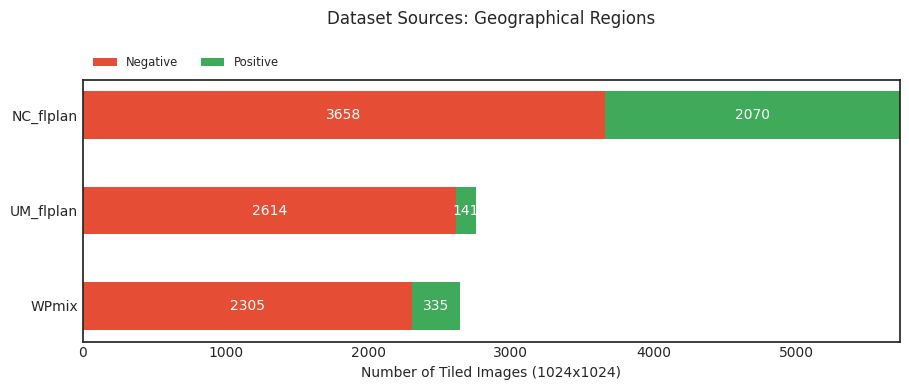

In [79]:

counts = {
    'negative_NC_flplan': 3658,
    'positive_WPmix':      335,
    'positive_UM_flplan':  141,
    'positive_NC_flplan': 2070,
    'negative_WPmix':     2305,
    'negative_UM_flplan': 2614,
}

datasets = sorted(set(k.split("_", 1)[1] for k in counts))
category_names = ['Negative', 'Positive']
results = {
    ds: [counts[f"negative_{ds}"], counts[f"positive_{ds}"]]
    for ds in datasets
}

labels = list(results.keys())
data = np.array(list(results.values()))
data_cum = data.cumsum(axis=1)

with plt.style.context("seaborn-v0_8-white"):
    category_colors = plt.colormaps['RdYlGn'](
        np.linspace(0.15, 0.85, data.shape[1]))

    fig, ax = plt.subplots(figsize=(9.2, 4))
    ax.invert_yaxis()
    #ax.xaxis.set_visible(False)
    ax.set_xlim(0, np.sum(data, axis=1).max())
    ax.set_xlabel("Number of Tiled Images (1024x1024)")

    for i, (colname, color) in enumerate(zip(category_names, category_colors)):
        widths = data[:, i]
        starts = data_cum[:, i] - widths
        rects = ax.barh(labels, widths, left=starts, height=0.5,
                        label=colname, color=color)
        r, g, b, _ = color
        text_color = 'white' if r * g * b < 0.5 else 'darkgrey'
        ax.bar_label(rects, label_type='center', color=text_color)

    
    ax.legend(ncols=len(category_names), bbox_to_anchor=(0, 1),
                loc='lower left', fontsize='small')
    ax.set_title("Dataset Sources: Geographical Regions", pad=40)
        
    plt.tight_layout()
    plt.show()

In [48]:
view_wpmix = dataset.match(
    ViewField("dataset_sr").contains_str('WPmix')
)
dd = view_wpmix.count_values("mission_name")

In [54]:
df

,Source Dataset
UM,1185
FRIWEN,945
MANTASANDY,105
GAM,405


Text(0.5, 0.98, 'WP Mix Dataset \n Manual and FLPLAN flights')

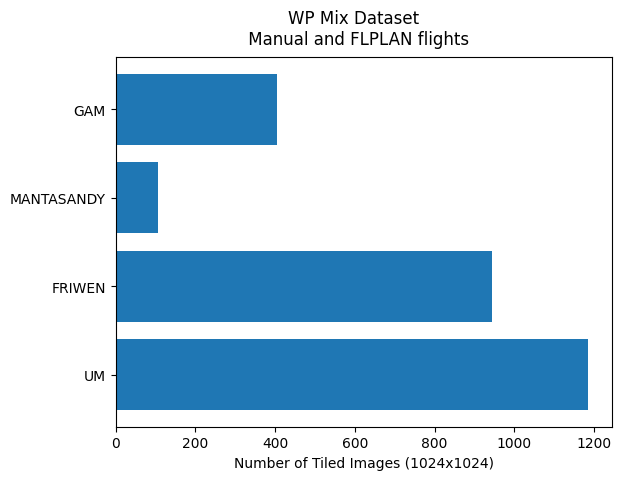

In [75]:
df = pd.DataFrame(data=dd.values(), index=dd.keys(),columns=['Source Dataset'])
fig, ax = plt.subplots(1,1)
ax.barh(
    df.index,
    df['Source Dataset'].values,
    height=0.8,
)
ax.set_xlabel("Number of Tiled Images (1024x1024)")
fig.suptitle('WP Mix Dataset \n Manual and FLPLAN flights')

# Extract Dinov3 features

- Input dimension 1204x1024
- Patch Token Size: 128 

In [7]:
ALL_REGION_LABELS    = ["NC", "WP", "UM"]
ALL_SUBREGION_LABELS = ["FRIWEN", "GAM", "MANTASANDY", "UM"]   # extend as needed
_ALL_LABELS = sorted(set(ALL_REGION_LABELS) | set(ALL_SUBREGION_LABELS))
 
 
def _build_palette_from_active_style(labels):
    """
    Builds a {label: color} mapping by pulling colors directly from the
    CURRENTLY ACTIVE style's axes.prop_cycle, rather than hardcoding a
    colormap like tab10. This means the palette automatically follows
    whatever style is active via plt.style.use(...) at call time -- so
    switching styles between cells changes the palette too, without
    needing to touch this function.
 
    If there are more labels than colors in the cycle, colors repeat
    (wrap around) rather than erroring, since some styles (e.g. ggplot)
    have fewer built-in colors than others (e.g. tab10-based cycles).
    """
    cycle_colors = [d["color"] for d in plt.rcParams["axes.prop_cycle"]]
    return {
        lab: cycle_colors[i % len(cycle_colors)]
        for i, lab in enumerate(labels)
    }
 
 
# Built fresh from whichever style is active at import time. Call
# _build_palette_from_active_style(_ALL_LABELS) again after switching
# styles if you want GLOBAL_PALETTE to reflect the new style too.
GLOBAL_PALETTE = _build_palette_from_active_style(_ALL_LABELS)

In [8]:
umap_coords = dataset.values("umap")
coords_2d_tsne = umap_coords

In [9]:
new_correct = []
for f in dataset.values('mission_name'):
    if 'Flight_' in f:
        new_correct.append('NC')
    else:
        new_correct.append(f)

In [97]:
pd.Series(new_correct).unique()

<ArrowStringArray>
['NC', 'UM', 'MANTASANDY', 'FRIWEN', 'GAM']
Length: 5, dtype: str

In [12]:
dataset.set_values('subregion',new_correct)

In [ ]:
joint_region = dataset.values("dataset_sr")
joint_subregion = dataset.values("subregion")

umap_coords = dataset.values("umap")
coords_2d_tsne = umap_coords

In [18]:
print("dataset_sr values:", sorted(set(joint_region)))
print("subregion values:", sorted(set(joint_subregion)))
print("_ALL_LABELS:", set(joint_region)|set(joint_subregion))

dataset_sr values: [np.str_('NC_flplan'), np.str_('UM_flplan'), np.str_('WPmix')]
subregion values: [np.str_('FRIWEN'), np.str_('GAM'), np.str_('MANTASANDY'), np.str_('NC'), np.str_('UM')]
_ALL_LABELS: {np.str_('NC_flplan'), np.str_('WPmix'), np.str_('FRIWEN'), np.str_('UM_flplan'), np.str_('UM'), np.str_('NC'), np.str_('GAM'), np.str_('MANTASANDY')}


In [22]:
set(joint_region)

{np.str_('NC_flplan'), np.str_('UM_flplan'), np.str_('WPmix')}

In [23]:
_ALL_LABELS = ['FRIWEN', 'GAM', 'MANTASANDY', 'NC', 'UM', 'WP','NC_flplan','UM_flplan','WPmix']

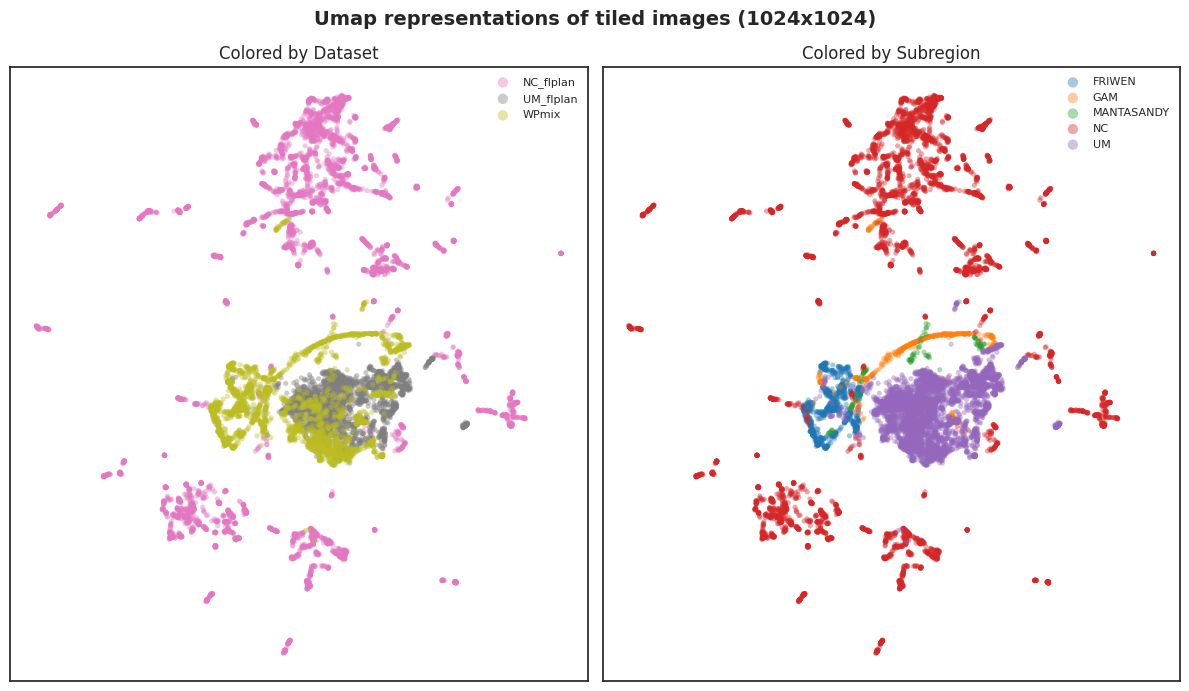

In [27]:

joint_region    = np.array(dataset.values("dataset_sr"))
joint_subregion = np.array(dataset.values("subregion"))
coords_2d_tsne  = np.array(dataset.values("umap"))   # (N, 2)

# ── t-SNE only: region (left) vs subregion (right) ──────────────────────────
with plt.style.context('seaborn-v0_8-white'):
    palette = _build_palette_from_active_style(_ALL_LABELS)   # reflects this style only

    fig, axes = plt.subplots(1, 2, figsize=(12, 7))

    for ax, color_labels, panel_title in zip(
        axes, [joint_region, joint_subregion], ["Colored by Dataset", "Colored by Subregion"]
    ):
        for lab in sorted(set(color_labels)):
            mask = color_labels == lab
            ax.scatter(
                coords_2d_tsne[mask, 0], coords_2d_tsne[mask, 1],
                s=14, alpha=0.4, color=palette[lab], label=lab, edgecolors="none",
            )
        ax.set_title(panel_title, fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.legend(fontsize=8, markerscale=2)

    fig.suptitle("Umap representations of tiled images (1024x1024)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Classification Results

Binary classification of all image tiles:
- Logistic Regression
- Random Forest
- MLP

In [31]:
df_nc_results = pd.read_parquet("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/results_classification/nctrained_UMtest.parquet")
df_wpnoum_results = pd.read_parquet("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/results_classification/nctrained_WPmixnoUM_UMtest.parquet")
df_wpmix_results = pd.read_parquet("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter3/results_classification/nctrained_WPmixALL_UMtest.parquet")

In [32]:
df_concat = pd.concat([df_nc_results,df_wpnoum_results,df_wpmix_results])

In [34]:
df_results = df_concat.copy()

In [36]:
# ── Precision-Recall curves: dropdown selects DOMAIN_SHIFT, one curve per model ──
import plotly.graph_objects as go
from sklearn.metrics import precision_recall_curve, average_precision_score, auc

domain_shifts = df_results["DOMAIN_SHIFT"].unique().tolist()
models        = df_results["model"].unique().tolist()

# Fixed color per model so it stays consistent across dropdown selections
model_colors = {
    "Logistic Regression": "#378ADD",
    "Random Forest":       "#1D9E75",
    "MLP":                 "#D85A30",
}

fig = go.Figure()

# One trace per (domain_shift, model) combo -- only the first domain_shift's
# traces start visible, dropdown toggles visibility of the rest.
trace_meta = []   # (domain_shift, model) for each trace, in the order added

for ds in domain_shifts:
    for model in models:
        sub = df_results[(df_results["DOMAIN_SHIFT"] == ds) & (df_results["model"] == model)]
        if sub.empty:
            continue

        precision, recall, _ = precision_recall_curve(sub["y_true"], sub["y_proba"])
        ap = average_precision_score(sub["y_true"], sub["y_proba"])
        auc_ = auc(sub["y_true"],sub["y_proba"])
        fig.add_trace(go.Scatter(
            x=recall, y=precision,
            mode="lines",
            name=f"{model} (AP={ap:.3f}) (AUC={auc_:.3f})",
            line=dict(color=model_colors.get(model, "#888780"), width=2),
            visible=(ds == domain_shifts[0]),   # only first domain_shift shown initially
        ))
        trace_meta.append((ds, model))

# ── Dropdown: one button per domain_shift, toggling trace visibility ────────
buttons = []
for ds in domain_shifts:
    visibility = [meta_ds == ds for (meta_ds, _) in trace_meta]
    buttons.append(dict(
        label=ds,
        method="update",
        args=[{"visible": visibility},
              {"title": f"Precision-Recall Curve — {ds}"}],
    ))

fig.update_layout(
    title=f"Precision-Recall Curve — {domain_shifts[0]}",
    xaxis_title="Recall",
    yaxis_title="Precision",
    xaxis=dict(range=[0, 1]),
    yaxis=dict(range=[0, 1.02]),
    updatemenus=[dict(
        type="dropdown",
        buttons=buttons,
        x=1.0, xanchor="right",
        y=1.18, yanchor="top",
    )],
    legend=dict(x=1.02, y=1, xanchor="left"),
    width=750, height=550,
)

fig.show()

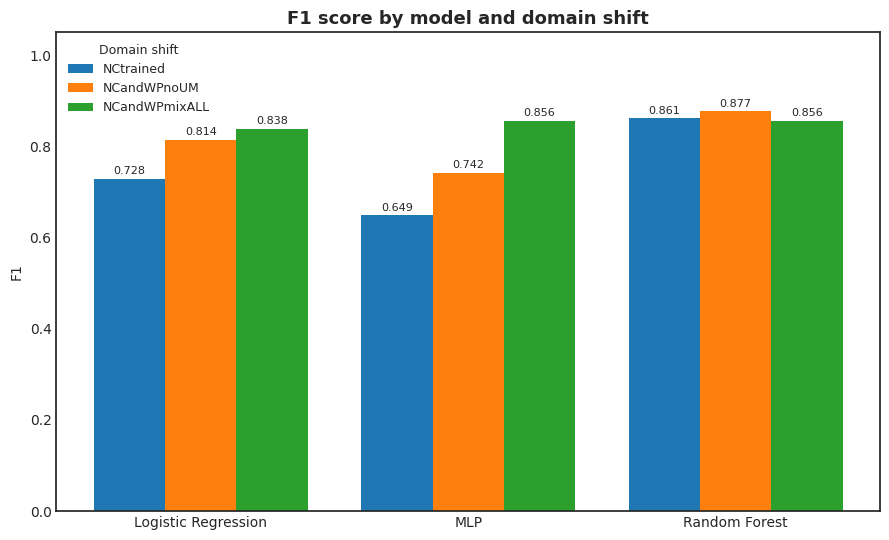

In [37]:
# ── F1 score grouped bar plot: model x domain_shift ──────────────────────────
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

def compute_metric_table(df, metric="f1"):
    """
    Computes one metric per (model, DOMAIN_SHIFT) combo from raw per-sample
    predictions in df_results.
    """
    metric_fns = {
        "f1":        lambda y_t, y_p: f1_score(y_t, y_p, zero_division=0),
        "precision": lambda y_t, y_p: precision_score(y_t, y_p, zero_division=0),
        "recall":    lambda y_t, y_p: recall_score(y_t, y_p, zero_division=0),
        "accuracy":  lambda y_t, y_p: accuracy_score(y_t, y_p),
    }
    score_fn = metric_fns[metric]

    rows = []
    for (model, ds), sub in df.groupby(["model", "DOMAIN_SHIFT"]):
        score = score_fn(sub["y_true"], sub["y_pred"])
        rows.append({"model": model, "DOMAIN_SHIFT": ds, metric: score})

    return pd.DataFrame(rows)


metric_name = "f1"
metric_df = compute_metric_table(df_results, metric=metric_name)

# ── Grouped bar plot ──────────────────────────────────────────────────────────
with plt.style.context('seaborn-v0_8-white'):
    models         = sorted(metric_df["model"].unique())
    domain_shifts  = ["NCtrained", "NCandWPnoUM", "NCandWPmixALL"]   # fixed, meaningful order
    domain_shifts  = [d for d in domain_shifts if d in metric_df["DOMAIN_SHIFT"].unique()]

    palette = _build_palette_from_active_style(domain_shifts)

    x = np.arange(len(models))
    n_groups = len(domain_shifts)
    bar_width = 0.8 / n_groups

    fig, ax = plt.subplots(figsize=(9, 5.5))

    for i, ds in enumerate(domain_shifts):
        heights = [
            metric_df.loc[(metric_df["model"] == m) & (metric_df["DOMAIN_SHIFT"] == ds), metric_name].values
            for m in models
        ]
        heights = [h[0] if len(h) else 0 for h in heights]

        offset = (i - (n_groups - 1) / 2) * bar_width
        bars = ax.bar(x + offset, heights, width=bar_width, label=ds, color=palette[ds])
        ax.bar_label(bars, fmt="%.3f", fontsize=8, padding=2)

    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylabel(metric_name.upper())
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{metric_name.upper()} score by model and domain shift", fontsize=13, fontweight="bold")
    ax.legend(title="Domain shift", fontsize=9, title_fontsize=9)

    plt.tight_layout()
    plt.show()

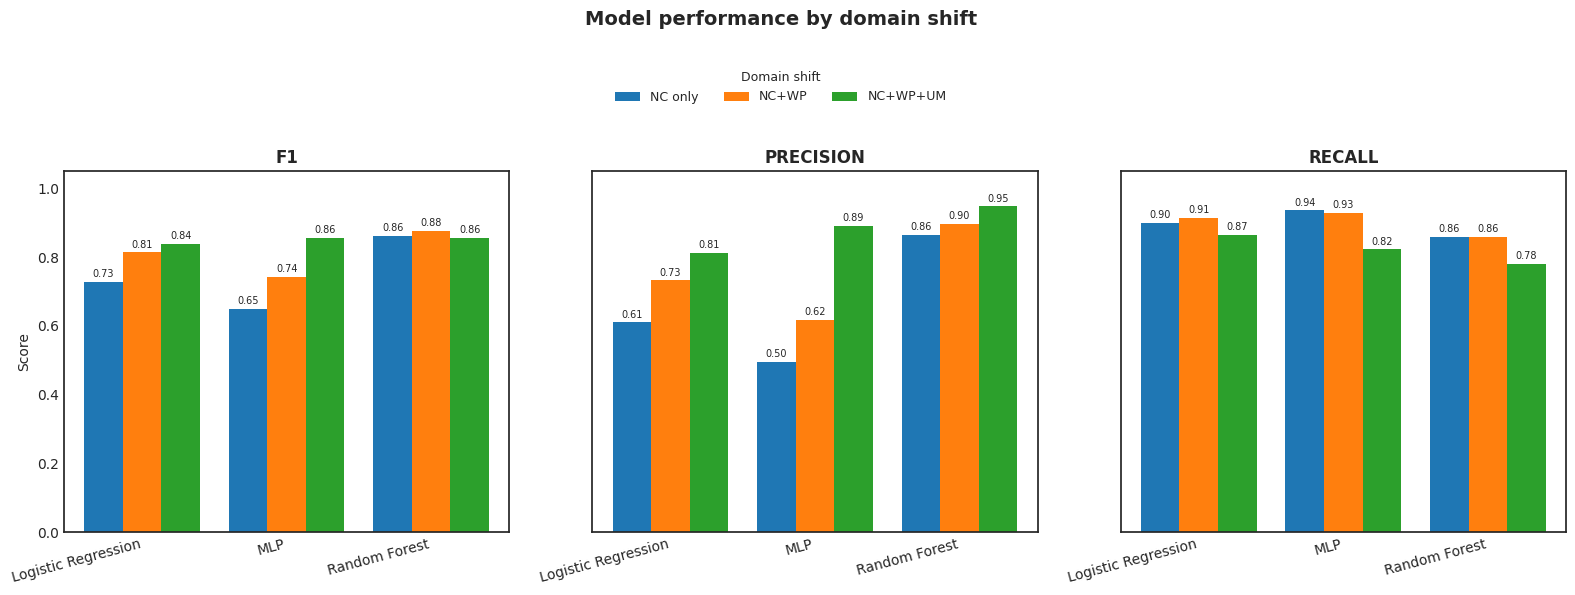

In [38]:
# ── F1 / Precision / Recall grouped bar plots, 3 subplots, custom domain_shift labels ──
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

def compute_metric_table(df, metric="f1"):
    """Computes one metric per (model, DOMAIN_SHIFT) combo from raw per-sample predictions."""
    metric_fns = {
        "f1":        lambda y_t, y_p: f1_score(y_t, y_p, zero_division=0),
        "precision": lambda y_t, y_p: precision_score(y_t, y_p, zero_division=0),
        "recall":    lambda y_t, y_p: recall_score(y_t, y_p, zero_division=0),
        "accuracy":  lambda y_t, y_p: accuracy_score(y_t, y_p),
    }
    score_fn = metric_fns[metric]

    rows = []
    for (model, ds), sub in df.groupby(["model", "DOMAIN_SHIFT"]):
        score = score_fn(sub["y_true"], sub["y_pred"])
        rows.append({"model": model, "DOMAIN_SHIFT": ds, metric: score})

    return pd.DataFrame(rows)


def plot_metric_grid(
    df,
    metrics=("f1", "precision", "recall"),
    domain_shift_order=("NCtrained", "NCandWPnoUM", "NCandWPmixALL"),
    domain_shift_label=None,
    style="seaborn-v0_8-white",
    figsize=(16, 5),
):
    """
    Parameters
    ----------
    df                  : df_results (per-sample predictions, concatenated across models)
    metrics             : tuple of metric names, one subplot each
    domain_shift_order  : tuple -- raw DOMAIN_SHIFT values, fixes x-group order
    domain_shift_label  : list or None -- display labels, SAME LENGTH AND ORDER
                            as domain_shift_order. None = use raw values as-is.
    style               : matplotlib style name
    """
    domain_shift_order = [d for d in domain_shift_order if d in df["DOMAIN_SHIFT"].unique()]

    if domain_shift_label is not None:
        assert len(domain_shift_label) == len(domain_shift_order), (
            f"domain_shift_label has {len(domain_shift_label)} entries but "
            f"domain_shift_order has {len(domain_shift_order)} -- they must match."
        )
        label_map = dict(zip(domain_shift_order, domain_shift_label))
    else:
        label_map = {d: d for d in domain_shift_order}

    models = sorted(df["model"].unique())

    with plt.style.context(style):
        palette = _build_palette_from_active_style(domain_shift_order)

        fig, axes = plt.subplots(1, len(metrics), figsize=figsize, sharey=True)
        if len(metrics) == 1:
            axes = [axes]

        x = np.arange(len(models))
        n_groups = len(domain_shift_order)
        bar_width = 0.8 / n_groups

        for ax, metric_name in zip(axes, metrics):
            metric_df = compute_metric_table(df, metric=metric_name)

            for i, ds in enumerate(domain_shift_order):
                heights = [
                    metric_df.loc[(metric_df["model"] == m) & (metric_df["DOMAIN_SHIFT"] == ds), metric_name].values
                    for m in models
                ]
                heights = [h[0] if len(h) else 0 for h in heights]

                offset = (i - (n_groups - 1) / 2) * bar_width
                bars = ax.bar(x + offset, heights, width=bar_width,
                              label=label_map[ds], color=palette[ds])
                ax.bar_label(bars, fmt="%.2f", fontsize=7, padding=2)

            ax.set_xticks(x)
            ax.set_xticklabels(models, rotation=15, ha="right")
            ax.set_title(metric_name.upper(), fontsize=12, fontweight="bold")
            ax.set_ylim(0, 1.05)

        axes[0].set_ylabel("Score")
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, title="Domain shift", loc="upper center",
                  bbox_to_anchor=(0.5, 1.08), ncol=n_groups, fontsize=9, title_fontsize=9)

        fig.suptitle("Model performance by domain shift", fontsize=14, fontweight="bold", y=1.18)
        plt.tight_layout()
        plt.show()

    return fig, axes


# ── Run ───────────────────────────────────────────────────────────────────────
fig, axes = plot_metric_grid(
    df_results,
    metrics=("f1", "precision", "recall"),
    domain_shift_order=("NCtrained", "NCandWPnoUM", "NCandWPmixALL"),
    domain_shift_label=["NC only", "NC+WP", "NC+WP+UM"],
)

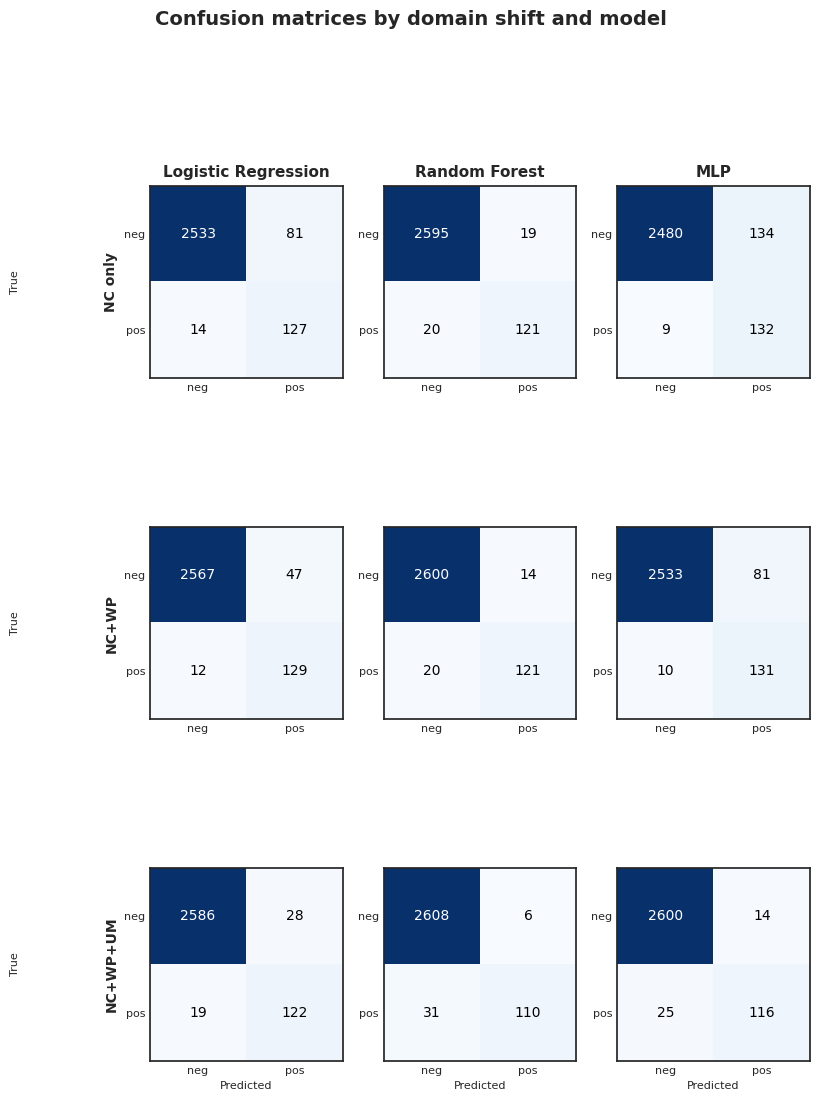

In [39]:
# ── Confusion matrices grid: rows = domain_shift, columns = model (A4 size) ──
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix_grid(
    df,
    domain_shift_order=("NCtrained", "NCandWPnoUM", "NCandWPmixALL"),
    domain_shift_label=None,
    model_order=("Logistic Regression", "Random Forest", "MLP"),
    style="seaborn-v0_8-white",
    cmap="Blues",
    figsize=(8.27, 11.69),   # A4 portrait in inches
):
    """
    Parameters
    ----------
    df                  : df_results (per-sample predictions, concatenated across models)
    domain_shift_order  : tuple -- raw DOMAIN_SHIFT values, fixes row order
    domain_shift_label  : list or None -- display labels for rows, SAME LENGTH
                            AND ORDER as domain_shift_order. None = use raw values.
    model_order         : tuple -- fixes column order
    style               : matplotlib style name
    cmap                : colormap for the confusion matrix cells
    figsize             : default A4 portrait (8.27in x 11.69in)
    """
    domain_shift_order = [d for d in domain_shift_order if d in df["DOMAIN_SHIFT"].unique()]
    model_order         = [m for m in model_order if m in df["model"].unique()]

    if domain_shift_label is not None:
        assert len(domain_shift_label) == len(domain_shift_order), (
            f"domain_shift_label has {len(domain_shift_label)} entries but "
            f"domain_shift_order has {len(domain_shift_order)} -- they must match."
        )
        label_map = dict(zip(domain_shift_order, domain_shift_label))
    else:
        label_map = {d: d for d in domain_shift_order}

    n_rows = len(domain_shift_order)
    n_cols = len(model_order)

    with plt.style.context(style):
        fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
        if n_rows == 1:
            axes = axes.reshape(1, -1)
        if n_cols == 1:
            axes = axes.reshape(-1, 1)

        for i, ds in enumerate(domain_shift_order):
            for j, model in enumerate(model_order):
                ax = axes[i, j]
                sub = df[(df["DOMAIN_SHIFT"] == ds) & (df["model"] == model)]

                if sub.empty:
                    ax.axis("off")
                    continue

                cm = confusion_matrix(sub["y_true"], sub["y_pred"])
                im = ax.imshow(cm, cmap=cmap, vmin=0)

                for r in range(cm.shape[0]):
                    for c in range(cm.shape[1]):
                        val = cm[r, c]
                        text_color = "white" if val > cm.max() / 2 else "black"
                        ax.text(c, r, str(val), ha="center", va="center",
                                fontsize=10, color=text_color)

                ax.set_xticks([0, 1])
                ax.set_yticks([0, 1])
                ax.set_xticklabels(["neg", "pos"], fontsize=8)
                ax.set_yticklabels(["neg", "pos"], fontsize=8)

                if i == 0:
                    ax.set_title(model, fontsize=11, fontweight="bold")
                if j == 0:
                    ax.set_ylabel(label_map[ds], fontsize=10, fontweight="bold")
                if i == n_rows - 1:
                    ax.set_xlabel("Predicted", fontsize=8)
                if j == 0:
                    ax.text(-0.7, 0.5, "True", fontsize=8, rotation=90,
                            va="center", ha="center", transform=ax.transAxes)

        fig.suptitle("Confusion matrices by domain shift and model",
                     fontsize=14, fontweight="bold", y=0.995)
        plt.tight_layout(rect=[0, 0, 1, 0.97])
        plt.show()

    return fig, axes


# ── Run ───────────────────────────────────────────────────────────────────────
fig, axes = plot_confusion_matrix_grid(
    df_results,
    domain_shift_order=("NCtrained", "NCandWPnoUM", "NCandWPmixALL"),
    domain_shift_label=["NC only", "NC+WP", "NC+WP+UM"],
    model_order=("Logistic Regression", "Random Forest", "MLP"),
)